**News Sentiment as a Trading Signal: Measuring Predictive Decay Across Holding Horizons**

Syed Sirajuddin · Master of Science in Applied Artificial Intelligence · Shiley Marcos School of Engineering, University of San Diego · AAI-590 Capstone

# Notebook 2 of 5 — Exploratory Data Analysis

**Execution order note:** this notebook consumes the scored news table produced by Notebook 03, so the run order is 01 → 03 → 02 → 04 → 05; it is numbered second because exploratory analysis logically precedes modeling in the report narrative.

This notebook examines both data streams — market prices and news sentiment inputs — before any modeling. The purpose of each analysis is stated up front so that the exploration is hypothesis-driven rather than incidental; interpretation cells are left as placeholders to be completed once the live data has been acquired, per the project schedule. The findings recorded here will constitute the Data Summary section of the final report.


In [1]:
%matplotlib inline
# Environment setup: resolve the repository root so `src` imports work
# whether this notebook is run from notebooks/ or the project root.
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
RANDOM_SEED = 42
from pathlib import Path
FIGDIR = ROOT / "reports" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

In [2]:
from dotenv import load_dotenv
load_dotenv(ROOT / ".env")

import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(message)s")

In [3]:
from src.config import PROCESSED_DIR
prices = pd.read_parquet(PROCESSED_DIR / "prices_clean.parquet")
news   = pd.read_parquet(PROCESSED_DIR / "news_scored.parquet")  # produced by Notebook 03
px = prices.pivot_table(index="date", columns="ticker", values="adj_close")
rets = px.pct_change()

## 1. Price Stream

### 1.1 Coverage and continuity
Before anything else, we verify that every ticker spans the full study window without unexplained gaps. Gaps concentrated in one vendor or one period would bias any cross-sectional comparison, and the longest holding horizon (126 trading days) is only testable where history is continuous.


In [4]:
coverage = prices.groupby("ticker")["date"].agg(["min", "max", "count"])
display(coverage)

# Trading-day continuity check: sessions per ticker vs. the union calendar
union_days = prices["date"].nunique()
gaps = (union_days - coverage["count"]).sort_values(ascending=False)
print("Sessions missing vs. union calendar (top 5):")
print(gaps.head())

,min,max,count
ticker,,,
AAPL,2020-01-02,2025-12-30,1507
AMD,2020-01-02,2025-12-30,1507
AMZN,2020-01-02,2025-12-30,1507
BA,2020-01-02,2025-12-30,1507
DIS,2020-01-02,2025-12-30,1507
GOOGL,2020-01-02,2025-12-30,1507
HD,2020-01-02,2025-12-30,1507
JNJ,2020-01-02,2025-12-30,1507
JPM,2020-01-02,2025-12-30,1507


Sessions missing vs. union calendar (top 5):
ticker
AAPL    0
AMD     0
AMZN    0
BA      0
DIS     0
Name: count, dtype: int64


### 1.2 Return distributions and volatility
Daily equity returns are well known to be heavy-tailed and volatility-clustered rather than normal (Cont, 2001). Confirming these stylized facts in our sample matters for two design choices made later: the backtest reports drawdown alongside the Sharpe ratio (since Sharpe alone understates tail risk), and the extreme-return winsorization rule from Notebook 01 must be shown to have trimmed only data errors, not genuine market events.


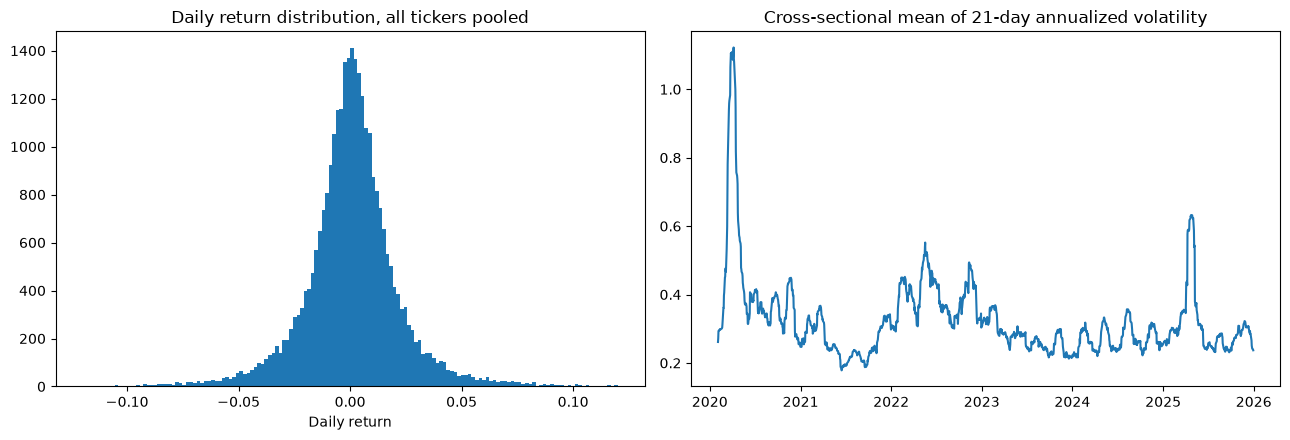

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(rets.to_numpy().ravel(), bins=150, range=(-0.12, 0.12))
axes[0].set_title("Daily return distribution, all tickers pooled")
axes[0].set_xlabel("Daily return")

roll_vol = rets.rolling(21).std().mean(axis=1) * np.sqrt(252)
axes[1].plot(roll_vol.index, roll_vol)
axes[1].set_title("Cross-sectional mean of 21-day annualized volatility")
plt.tight_layout(); plt.savefig(FIGDIR / "eda_returns_volatility.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.3 Cross-ticker correlation
Correlation among universe names governs how much diversification the portfolio layer of the backtest can achieve: if all twenty names move together, holding ten simultaneous positions is little safer than holding one. High average pairwise correlation would also mean signals firing on the same day are not independent bets — a fact the results discussion must account for.

**Interpretation — to be completed after execution.**


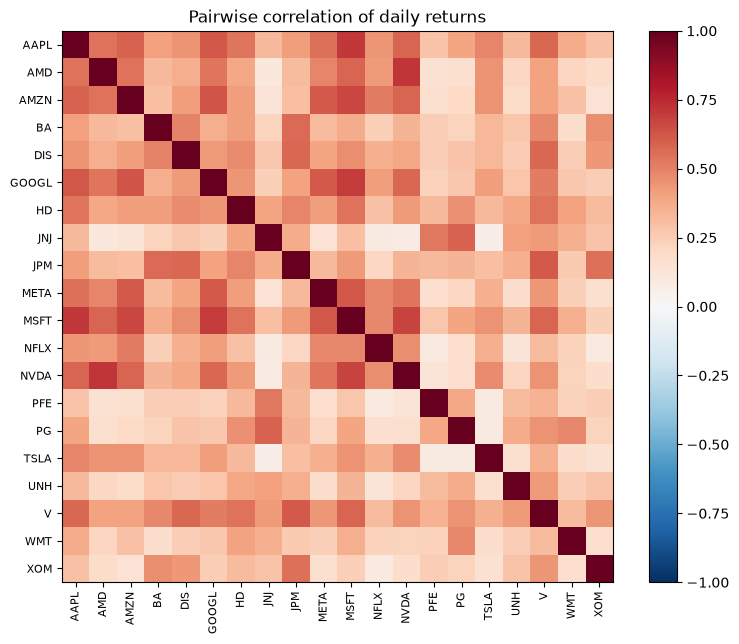

Mean pairwise correlation: 0.361


In [6]:
corr = rets.corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr)), corr.columns, fontsize=8)
fig.colorbar(im); ax.set_title("Pairwise correlation of daily returns")
plt.tight_layout(); plt.savefig(FIGDIR / "eda_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Mean pairwise correlation: "
      f"{corr.values[np.triu_indices_from(corr, k=1)].mean():.3f}")

## 2. News Stream

### 2.1 Article volume and coverage
Sentiment aggregates are only as reliable as the article counts beneath them. We examine weekly article volume over time (vendor coverage often improves in recent years, which can create a subtle recency bias) and per-ticker counts (mega-caps typically attract several times the coverage of the least-covered names). Both patterns inform the `min_articles` support threshold used in signal generation.


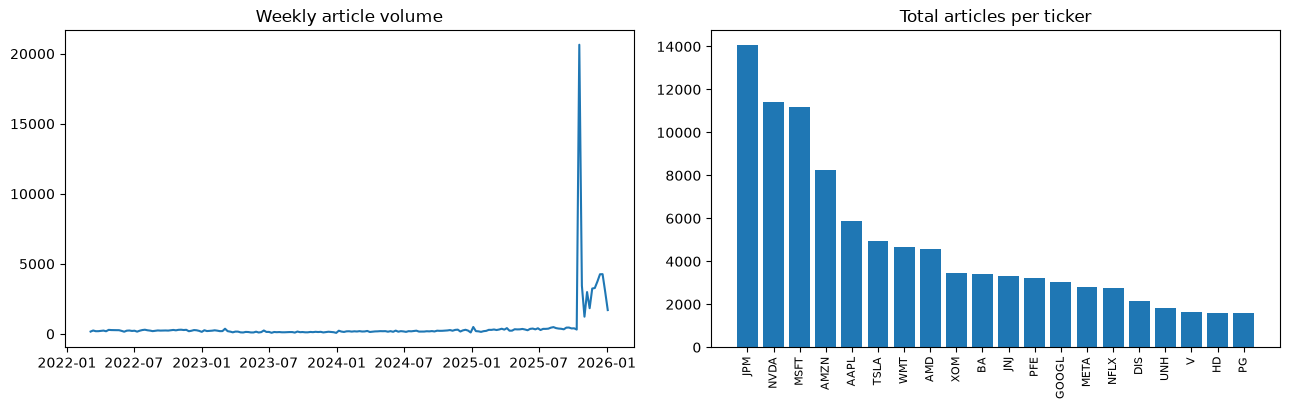

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
weekly = news.groupby(pd.Grouper(key="effective_date", freq="W")).size()
axes[0].plot(weekly.index, weekly.values)
axes[0].set_title("Weekly article volume")

per_ticker = news["ticker"].value_counts()
axes[1].bar(per_ticker.index, per_ticker.values)
axes[1].tick_params(axis="x", rotation=90, labelsize=8)
axes[1].set_title("Total articles per ticker")
plt.tight_layout(); plt.savefig(FIGDIR / "eda_news_volume.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.2 Sentiment score distribution
The scalar article score used throughout the project is *P(positive) − P(negative)* from the FinBERT classifier (introduced in Notebook 03), bounded in [−1, 1]. Its distribution determines whether the entry thresholds (±0.35 by default) are selective or trivially easy to cross. Financial news skews toward neutral corporate reporting, so a large central mass is expected; what matters is that the tails contain enough decisively toned articles to generate a workable number of signals.

**Interpretation — to be completed after execution.**


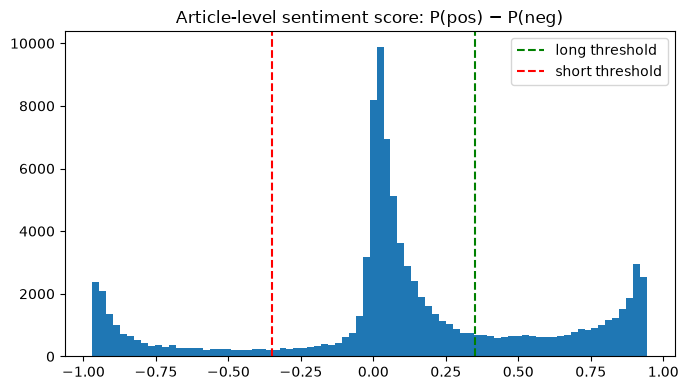

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(news["score"], bins=80)
ax.axvline(0.35, color="green", ls="--", label="long threshold")
ax.axvline(-0.35, color="red", ls="--", label="short threshold")
ax.set_title("Article-level sentiment score: P(pos) − P(neg)")
ax.legend(); plt.tight_layout(); plt.savefig(FIGDIR / "eda_sentiment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.3 The motivating relationship: sentiment vs. forward returns
Finally, the exploratory version of the project's core question: does daily aggregated sentiment relate to *next-day* returns at all? We use Spearman rank correlation, which is robust to the heavy tails documented in Section 1.2. Prior literature suggests the effect, where present, is real but small — Tetlock (2007) and Heston and Sinha (2017) report economically meaningful but statistically modest relationships — so a small positive rank correlation here would be consistent with the hypothesis, while a zero correlation would flag risk to the project early, in time for the Module 4 instructor meeting.

**Interpretation — to be completed after execution.**


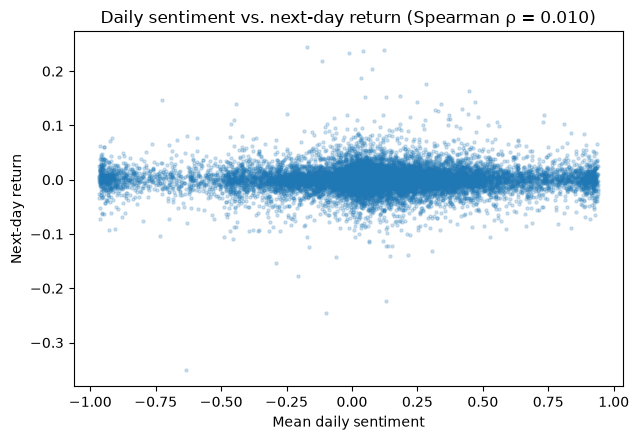

In [9]:
daily_sent = (news.groupby(["effective_date", "ticker"])["score"]
                  .mean().rename("sent").reset_index()
                  .rename(columns={"effective_date": "date"}))
fwd = px.pct_change().shift(-1).stack().rename("fwd_ret").reset_index()
joined = daily_sent.merge(fwd, on=["date", "ticker"]).dropna()

rho = joined["sent"].corr(joined["fwd_ret"], method="spearman")
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(joined["sent"], joined["fwd_ret"], s=5, alpha=0.2)
ax.set_xlabel("Mean daily sentiment"); ax.set_ylabel("Next-day return")
ax.set_title(f"Daily sentiment vs. next-day return (Spearman ρ = {rho:.3f})")
plt.tight_layout(); plt.savefig(FIGDIR / "eda_sentiment_vs_return.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Summary for the Data Summary Section

**To be completed after execution.** This cell will summarize: dataset dimensions and coverage; the count and cause of every row removed or modified by cleaning; the stylized facts confirmed in the price stream; news coverage asymmetries and their implications for the support threshold; and the preliminary sentiment–return relationship, which motivates (or cautions against) the modeling that follows.


---
### Acknowledgment of AI Tool Use

Portions of the code scaffolding and prose in this notebook were drafted with the assistance of Anthropic's Claude (Anthropic, 2026) and subsequently reviewed, tested, and revised by the author, who takes full responsibility for the final content, design decisions, and results. This acknowledgment is provided in accordance with University of San Diego academic integrity guidelines on the use of generative AI tools.

Anthropic. (2026). *Claude* [Large language model]. https://claude.ai

### References

Cont, R. (2001). Empirical properties of asset returns: Stylized facts and statistical issues. *Quantitative Finance, 1*(2), 223–236.

Heston, S. L., & Sinha, N. R. (2017). News vs. sentiment: Predicting stock returns from news stories. *Financial Analysts Journal, 73*(3), 67–83.

Tetlock, P. C. (2007). Giving content to investor sentiment: The role of media in the stock market. *The Journal of Finance, 62*(3), 1139–1168.
